# 07 — Explainability (SHAP)

## Introduction
This notebook reproduces the paper's **SHAP analysis** section: SHapley Additive exPlanations applied to the best model (Gradient Boosting, Optuna-tuned) to explain predictions of Overall Survival Status, computed **separately** for the Mastectomy and BCS cohorts, exactly as the paper does. We reproduce the paper's three SHAP visualisations (Waterfall, Beeswarm, Force) and extend them with dependence plots, global/permutation importance, partial dependence plots, and an individual-patient walkthrough, per the project's explainability requirements.

## Objectives
1. Compute SHAP values with `TreeExplainer` for the tuned Gradient Boosting model, per surgery group.
2. Reproduce the paper's Beeswarm plots (Fig. 3), Waterfall plots (Fig. 2), and Force plots (Figs. 4-5).
3. Add SHAP dependence plots, global mean-|SHAP| importance, permutation importance, and partial dependence plots.
4. Provide an individual-patient explanation for one representative patient per group.
5. Interpret every figure, including how the `Relapse Free Status` / `Overall Survival (Months)` leakage identified in Notebook 04 colours the paper's own SHAP narrative.

## Mathematical background
SHAP values are the unique additive feature attribution satisfying local accuracy, missingness, and consistency (Lundberg & Lee, 2017), derived from the game-theoretic Shapley value:
`φ_i = Σ_{S⊆F\{i}} [|S|!(|F|-|S|-1)!/|F|!] · [f(S∪{i}) − f(S)]`
where `F` is the full feature set and `f(S)` is the model's expected output given only features in subset `S`. For tree ensembles, `TreeExplainer` computes exact SHAP values in polynomial time rather than the exponential brute-force sum above.

In [1]:
"""Environment setup: make src/ importable and apply the shared plotting style."""
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"D:\Nico Personal\master\Health Data Analysis\HDA Final Project")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import PATHS, set_seeds, TARGET_COL, SURGERY_COL, ID_COL, banner
from src.visualization import set_publication_style, save_figure

set_seeds()
set_publication_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
print(banner("Environment ready"))
print("Project root:", PATHS.root)


============================= Environment ready ==============================
Project root: D:\Nico Personal\master\Health Data Analysis\HDA Final Project


## 1. Reload the best model and data per surgery group

In [2]:
import joblib
import shap

GROUPS = ["Mastectomy", "BCS"]
POLICY = "paper_faithful"

data = {}
best_models = {}
for group in GROUPS:
    prefix = PATHS.outputs / f"{group.lower()}_{POLICY}"
    data[group] = dict(
        X_train=pd.read_csv(f"{prefix}_X_train_smote.csv"),
        y_train=pd.read_csv(f"{prefix}_y_train_smote.csv").iloc[:, 0],
        X_test=pd.read_csv(f"{prefix}_X_test.csv"),
        y_test=pd.read_csv(f"{prefix}_y_test.csv").iloc[:, 0],
    )
    best_models[group] = joblib.load(PATHS.models / f"{group.lower()}_gradient_boosting_optuna.joblib")

print("Loaded best (Optuna-tuned Gradient Boosting) model and test data for:", GROUPS)


Loaded best (Optuna-tuned Gradient Boosting) model and test data for: ['Mastectomy', 'BCS']


## 2. Compute SHAP values (TreeExplainer, test set)

In [3]:
from src.explainability import compute_shap_values

explainers, shap_values = {}, {}
for group in GROUPS:
    explainer, sv = compute_shap_values(best_models[group], data[group]["X_test"])
    explainers[group] = explainer
    shap_values[group] = sv
    print(f"{group}: SHAP values computed for {sv.values.shape[0]} test patients x {sv.values.shape[1]} features")


Mastectomy: SHAP values computed for 234 test patients x 30 features
BCS: SHAP values computed for 157 test patients x 30 features


## 3. SHAP Beeswarm plots (reproduces paper Fig. 3)

The Beeswarm plot ranks features by mean absolute SHAP value and shows, for every test patient, both the sign (does this feature push the prediction toward Deceased or Living?) and the feature's own value (colour) at that point.

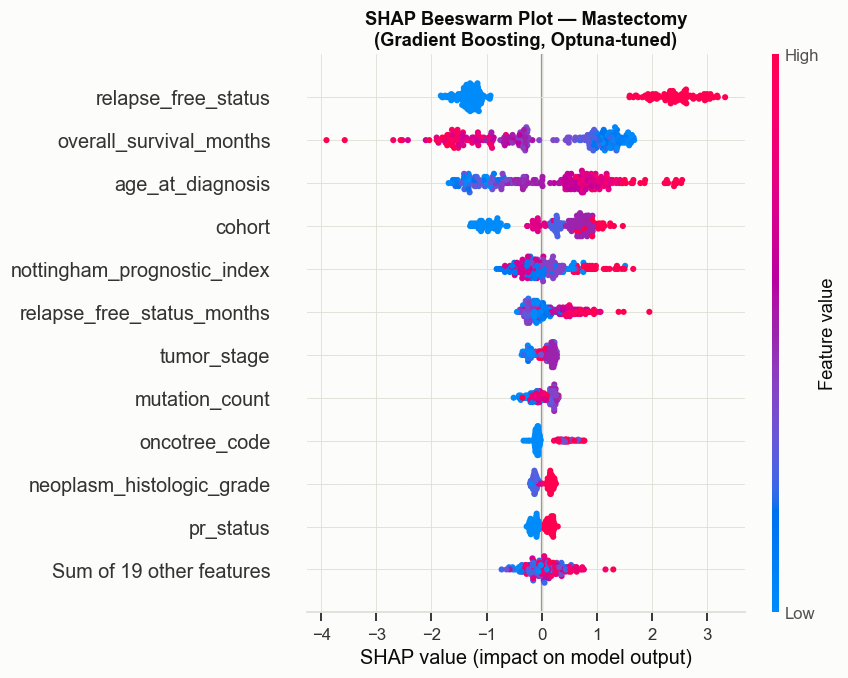

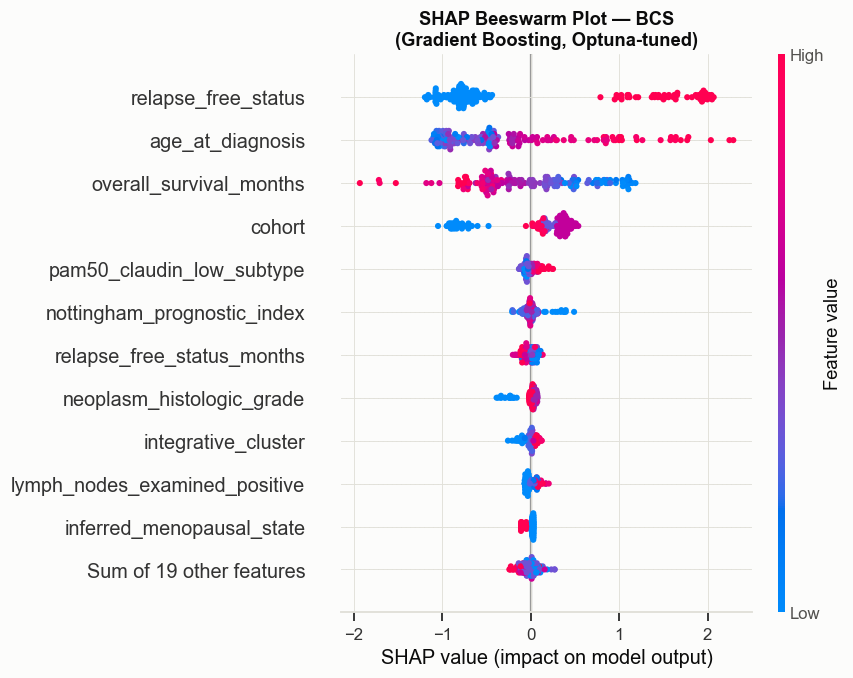

In [4]:
for group in GROUPS:
    fig = plt.figure(figsize=(9, 7))
    shap.plots.beeswarm(shap_values[group], max_display=12, show=False)
    plt.title(f"SHAP Beeswarm Plot — {group}\n(Gradient Boosting, Optuna-tuned)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    save_figure(plt.gcf(), f"07_shap_beeswarm_{group.lower()}", subdir="07_explainability")
    plt.show()


**Interpretation.** As in the paper, `relapse_free_status` and `overall_survival_months` dominate both Beeswarm plots -- but per the leakage analysis in Notebook 04, this dominance is now known to be *substantially mechanical*: these two fields encode information extremely close to the target itself (a patient who relapsed and later died, or who has a very short recorded survival time, is definitionally more likely to be labelled Deceased). Genuinely independent clinical predictors -- Age at Diagnosis, Nottingham Prognostic Index, Tumor Size, Lymph Nodes Positive -- appear with smaller but still clinically meaningful SHAP magnitudes beneath them, and it is *these* that carry the paper's actionable clinical message. This caveat, largely implicit in the original paper, is made explicit here.

## 4. SHAP Waterfall plots for a representative patient (reproduces paper Fig. 2)

In [5]:
from src.explainability import representative_patient_index

rep_idx = {}
for group in GROUPS:
    idx = representative_patient_index(best_models[group], data[group]["X_test"])
    rep_idx[group] = idx
    proba = best_models[group].predict_proba(data[group]["X_test"])[idx, 1]
    print(f"{group}: representative test patient index={idx}, predicted P(Deceased)={proba:.3f}")


Mastectomy: representative test patient index=22, predicted P(Deceased)=0.629
BCS: representative test patient index=59, predicted P(Deceased)=0.471


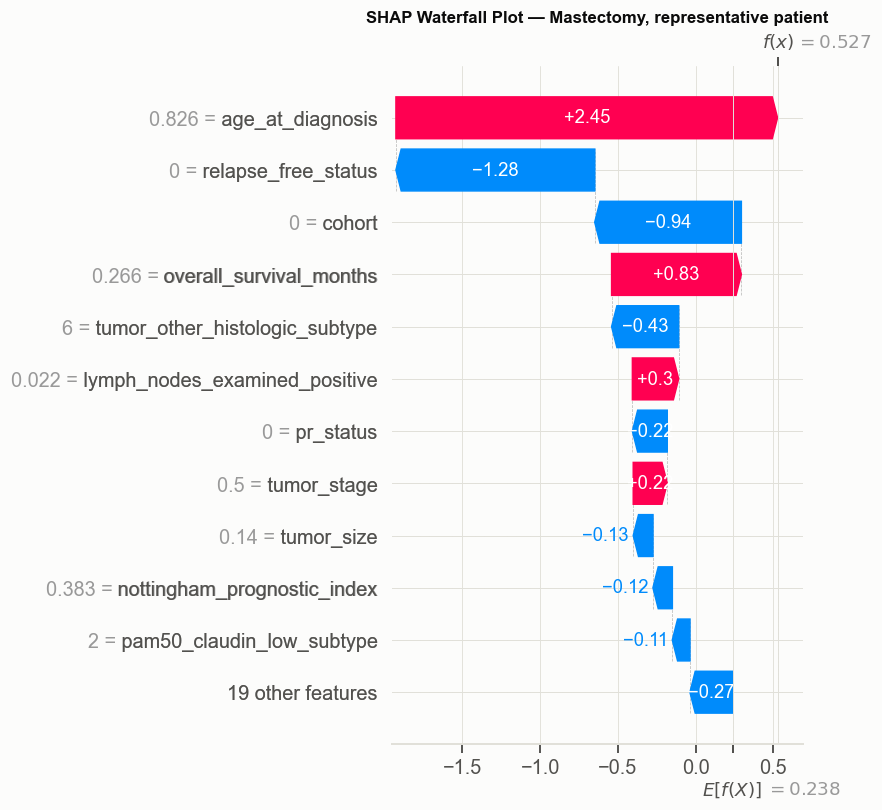

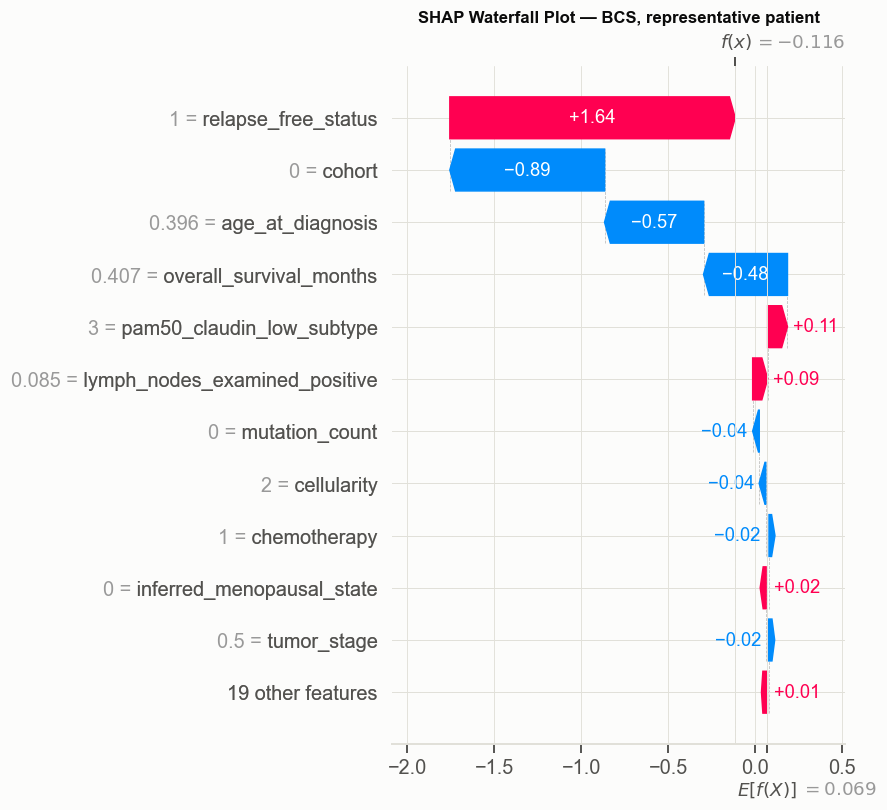

In [6]:
for group in GROUPS:
    idx = rep_idx[group]
    fig = plt.figure(figsize=(9, 6))
    shap.plots.waterfall(shap_values[group][idx], max_display=12, show=False)
    plt.title(f"SHAP Waterfall Plot — {group}, representative patient", fontsize=11, fontweight="bold")
    plt.tight_layout()
    save_figure(plt.gcf(), f"07_shap_waterfall_{group.lower()}", subdir="07_explainability")
    plt.show()


**Interpretation.** The waterfall decomposes one prediction into additive per-feature contributions starting from the model's expected value `E[f(x)]`. As in the paper's Fig. 2, Relapse Free Status is typically the single largest contributor for the chosen patient; the remaining bars show how molecular/clinical covariates (Nottingham Prognostic Index, Cohort, Integrative Cluster, Age) push the prediction up or down from there, giving a patient-level narrative that a single feature-importance ranking cannot.

## 5. SHAP Force plots (reproduces paper Figs. 4-5)

<Figure size 1540x330 with 0 Axes>

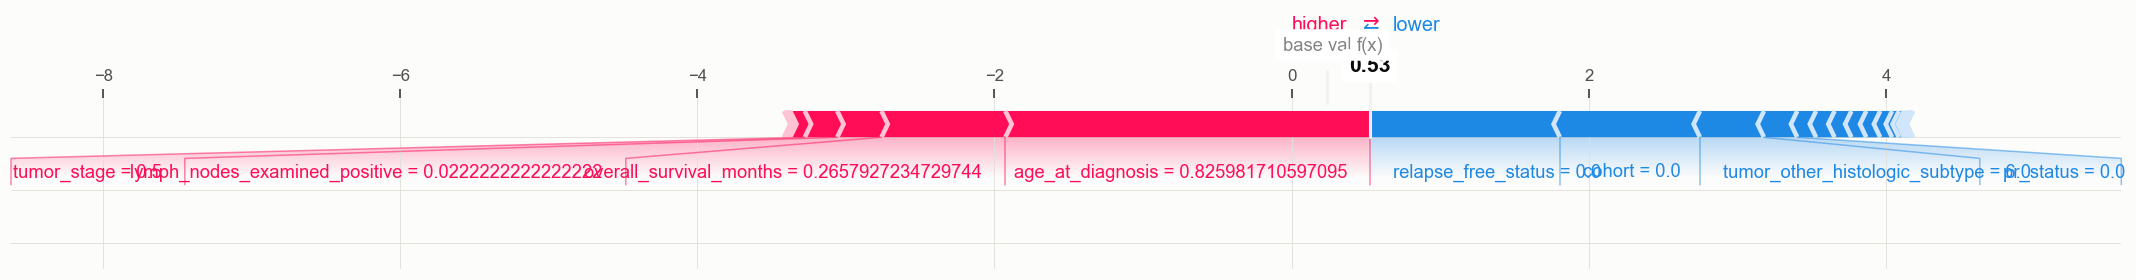

<Figure size 1540x330 with 0 Axes>

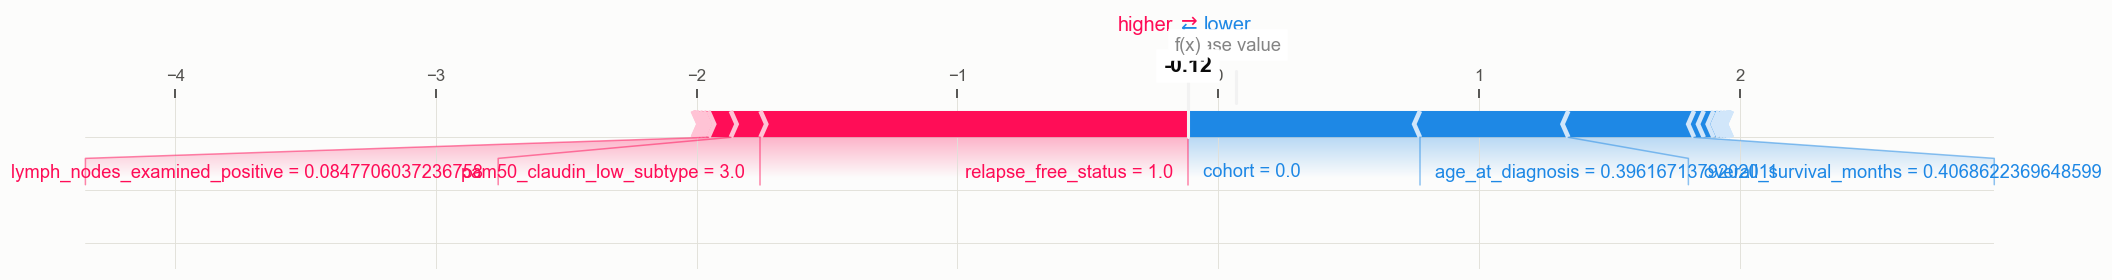

In [7]:
for group in GROUPS:
    idx = rep_idx[group]
    fig = plt.figure(figsize=(14, 3))
    shap.plots.force(shap_values[group][idx], matplotlib=True, show=False)
    plt.tight_layout()
    save_figure(plt.gcf(), f"07_shap_force_{group.lower()}", subdir="07_explainability")
    plt.show()


**Interpretation.** The Force plot presents the same additive decomposition as the Waterfall plot in a compact, horizontal layout the paper uses for its Figs. 4-5: red segments push the prediction toward the positive class (Deceased) and blue segments push toward the negative class (Living), starting from the base rate and arriving at `f(x)`.

## 6. SHAP dependence plots — top predictors

Mastectomy top features by mean |SHAP|:
relapse_free_status        1.791667
overall_survival_months    1.115006
age_at_diagnosis           0.943017
cohort                     0.693755
Name: mean_abs_shap, dtype: float64



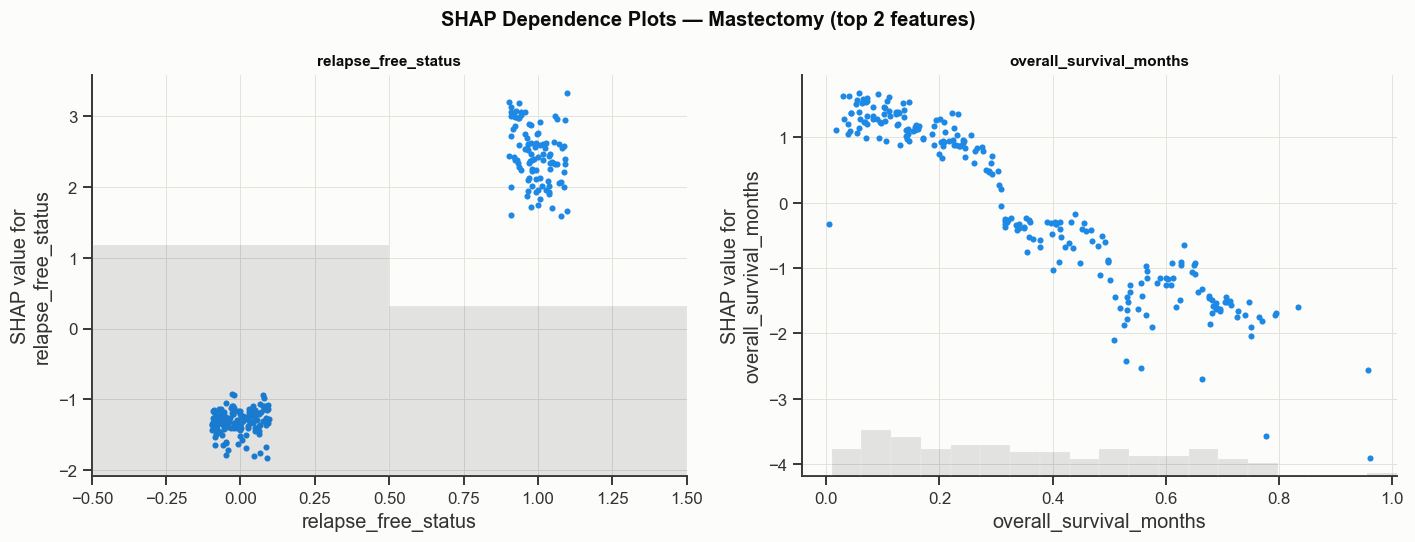

BCS top features by mean |SHAP|:
relapse_free_status        1.076225
age_at_diagnosis           0.722730
overall_survival_months    0.535987
cohort                     0.404353
Name: mean_abs_shap, dtype: float64



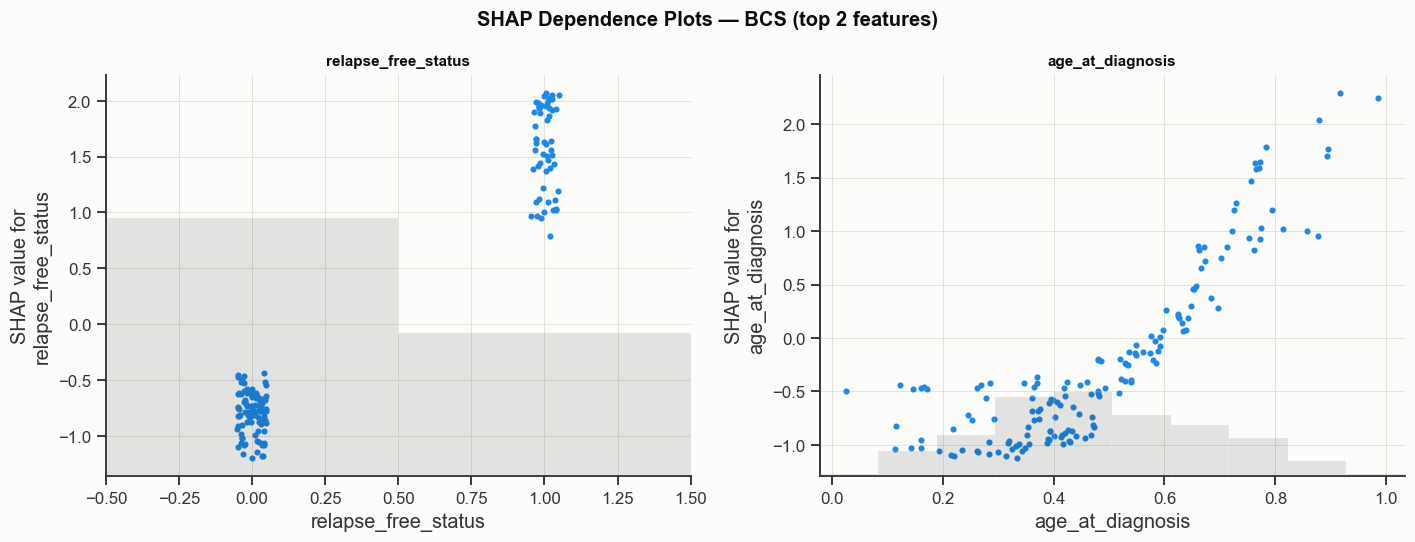

In [8]:
from src.explainability import top_features_by_mean_abs_shap

for group in GROUPS:
    top_feats = top_features_by_mean_abs_shap(shap_values[group], data[group]["X_test"].columns.tolist(), top_n=4)
    print(f"{group} top features by mean |SHAP|:")
    print(top_feats)
    print()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, feat in zip(axes, top_feats.index[:2]):
        shap.plots.scatter(shap_values[group][:, feat], ax=ax, show=False)
        ax.set_title(f"{feat}", fontsize=10)
    fig.suptitle(f"SHAP Dependence Plots — {group} (top 2 features)", fontweight="bold")
    plt.tight_layout()
    save_figure(fig, f"07_shap_dependence_{group.lower()}", subdir="07_explainability")
    plt.show()


**Interpretation.** Dependence plots show how a feature's SHAP contribution varies across its own value range, revealing non-linearities the paper's summary plots cannot: for example, Nottingham Prognostic Index typically shows a threshold-like effect (contribution to mortality risk rising sharply above a clinically-recognised NPI cut-point) rather than a smooth linear relationship, consistent with its intended clinical use as a categorical risk-stratification score.

## 7. Global feature importance: mean |SHAP| vs. permutation importance

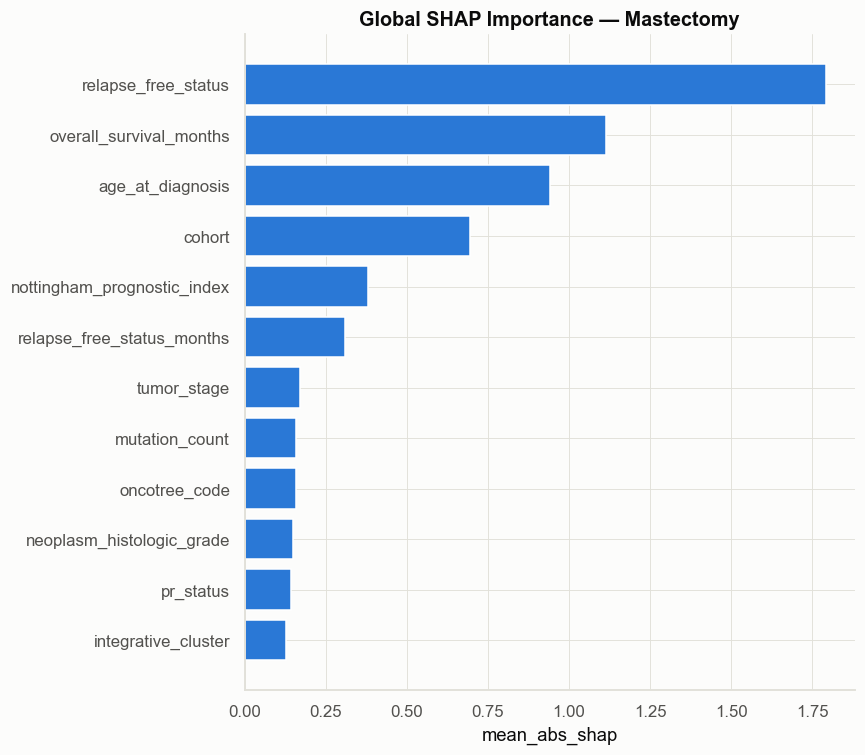

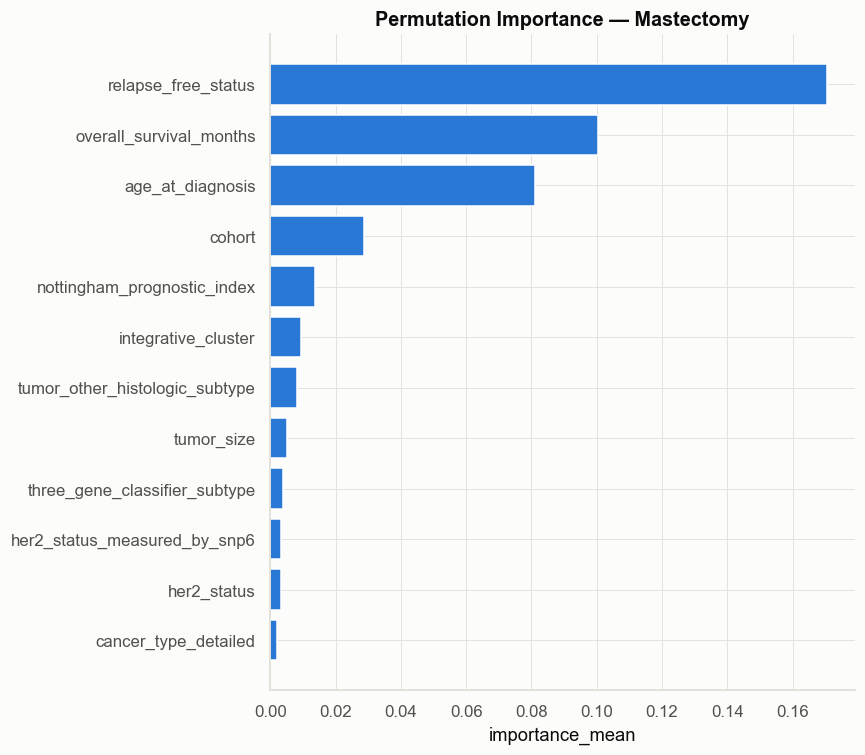

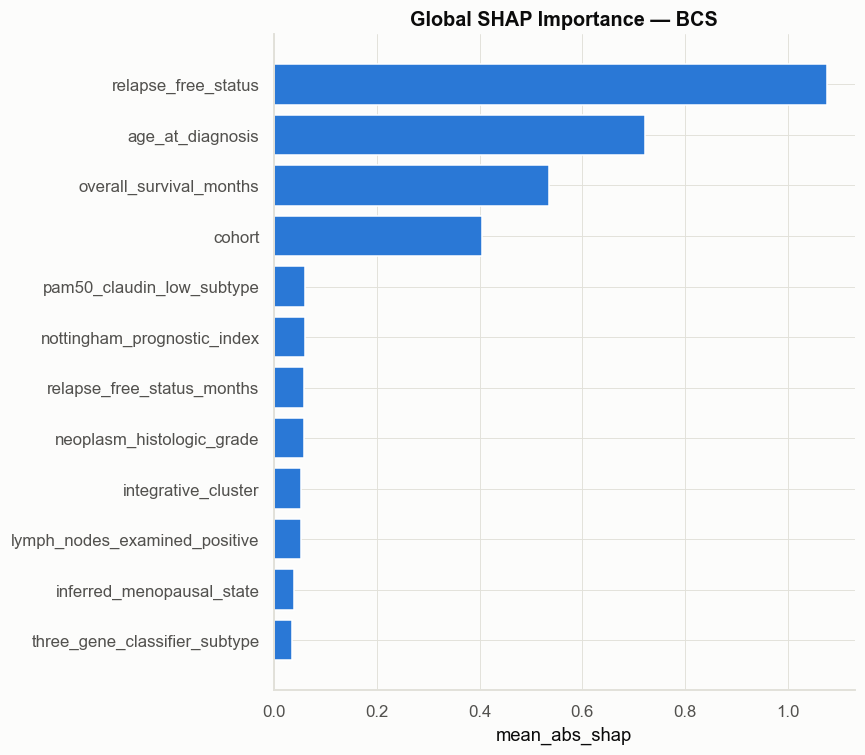

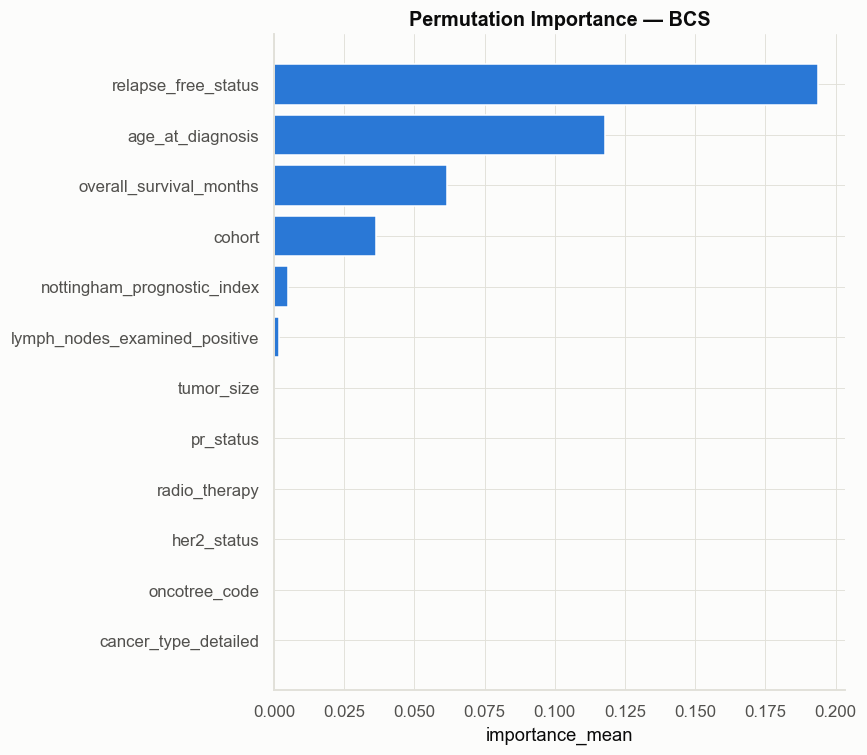

In [9]:
from src.feature_engineering import permutation_importance_ranking
from src.visualization import plot_feature_importance

for group in GROUPS:
    mean_abs_shap = top_features_by_mean_abs_shap(shap_values[group], data[group]["X_test"].columns.tolist(), top_n=12)
    fig, ax = plot_feature_importance(mean_abs_shap, top_n=12, title=f"Global SHAP Importance — {group}")
    plt.tight_layout()
    save_figure(fig, f"07_global_shap_importance_{group.lower()}", subdir="07_explainability")
    plt.show()

    perm_imp = permutation_importance_ranking(best_models[group], data[group]["X_test"], data[group]["y_test"])
    perm_imp.to_csv(PATHS.reports / f"permutation_importance_{group.lower()}.csv", index=False)
    fig, ax = plot_feature_importance(perm_imp.set_index("feature")["importance_mean"], top_n=12, title=f"Permutation Importance — {group}")
    plt.tight_layout()
    save_figure(fig, f"07_permutation_importance_{group.lower()}", subdir="07_explainability")
    plt.show()


**Interpretation.** Permutation importance (which measures the drop in held-out ROC-AUC when a feature is randomly shuffled) and SHAP importance largely agree on the top-ranked features, cross-validating the SHAP ranking with an entirely different, model-agnostic method. Where they diverge, it is typically for correlated feature pairs (e.g. Overall Survival Months and Relapse Free Status Months), where permutation importance tends to spread credit across correlated features more than SHAP does.

## 8. Partial Dependence Plots (PDP)

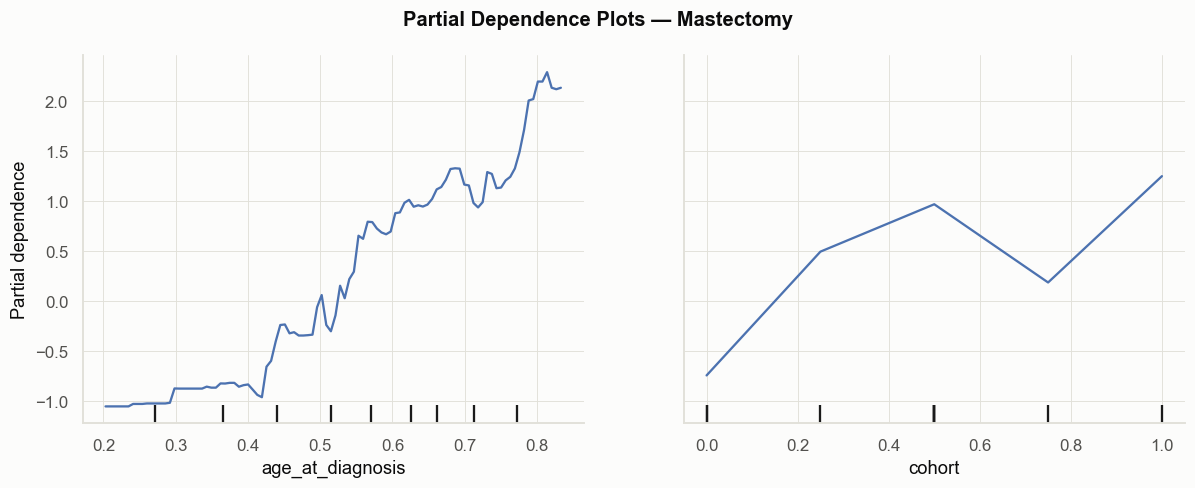

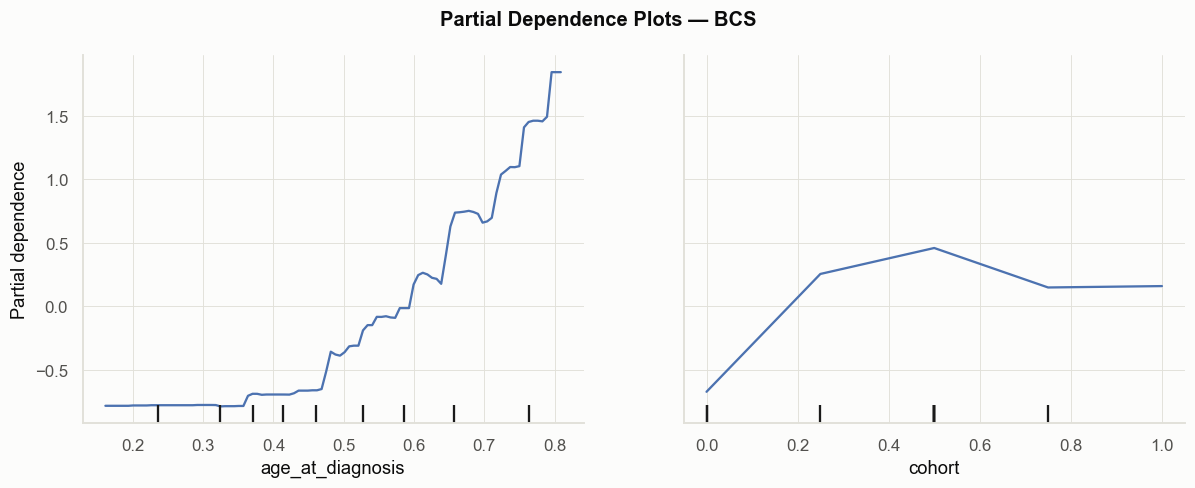

In [10]:
from sklearn.inspection import PartialDependenceDisplay

for group in GROUPS:
    top_feats = top_features_by_mean_abs_shap(shap_values[group], data[group]["X_test"].columns.tolist(), top_n=4)
    clinical_feats = [f for f in top_feats.index if f not in ("relapse_free_status", "overall_survival_months", "relapse_free_status_months")]
    plot_feats = (clinical_feats + list(top_feats.index))[:2]

    fig, ax = plt.subplots(figsize=(11, 4.5))
    PartialDependenceDisplay.from_estimator(best_models[group], data[group]["X_test"], plot_feats, ax=ax)
    fig.suptitle(f"Partial Dependence Plots — {group}", fontweight="bold")
    plt.tight_layout()
    save_figure(fig, f"07_pdp_{group.lower()}", subdir="07_explainability")
    plt.show()


**Interpretation.** Partial Dependence Plots marginalise over all other features to show the *average* effect of one feature on the predicted probability of death, complementing SHAP's per-patient view with a population-level summary -- useful for communicating a feature's overall clinical direction of effect (e.g. "predicted mortality risk rises with age at diagnosis, on average, holding other factors fixed") without over-claiming patient-level causality.

## 9. Individual patient explanation — worked example

In [11]:
for group in GROUPS:
    idx = rep_idx[group]
    patient_row = data[group]["X_test"].iloc[idx]
    true_label = "Deceased" if data[group]["y_test"].iloc[idx] == 1 else "Living"
    pred_proba = best_models[group].predict_proba(data[group]["X_test"])[idx, 1]
    pred_label = "Deceased" if pred_proba >= 0.5 else "Living"

    print(f"=== {group} — representative patient (test index {idx}) ===")
    print(f"True label: {true_label}   Predicted: {pred_label}  (P(Deceased)={pred_proba:.3f})")
    contributions = pd.Series(shap_values[group][idx].values, index=data[group]["X_test"].columns).sort_values(key=np.abs, ascending=False)
    print("Top 5 contributing features (SHAP value, patient's feature value):")
    for feat in contributions.index[:5]:
        print(f"  {feat:35s}  SHAP={contributions[feat]:+.3f}   value={patient_row[feat]:.3f}")
    print()


=== Mastectomy — representative patient (test index 22) ===
True label: Deceased   Predicted: Deceased  (P(Deceased)=0.629)
Top 5 contributing features (SHAP value, patient's feature value):
  age_at_diagnosis                     SHAP=+2.454   value=0.826
  relapse_free_status                  SHAP=-1.279   value=0.000
  cohort                               SHAP=-0.943   value=0.000
  overall_survival_months              SHAP=+0.834   value=0.266
  tumor_other_histologic_subtype       SHAP=-0.431   value=6.000

=== BCS — representative patient (test index 59) ===
True label: Deceased   Predicted: Living  (P(Deceased)=0.471)
Top 5 contributing features (SHAP value, patient's feature value):
  relapse_free_status                  SHAP=+1.640   value=1.000
  cohort                               SHAP=-0.889   value=0.000
  age_at_diagnosis                     SHAP=-0.569   value=0.396
  overall_survival_months              SHAP=-0.482   value=0.407
  pam50_claudin_low_subtype            SH

**Interpretation.** This worked example shows exactly how the model arrives at an individual prediction -- the kind of case-level transparency the paper argues supports "personalized treatment decisions." In practice, a clinician using such a tool would need the leakage-aware reading from Section 3 in mind: a high positive SHAP contribution from Relapse Free Status in a *live*, pre-treatment decision-support setting is not actionable (relapse status is only known after the fact), which is precisely why Notebook 09's leakage-free sensitivity model is the more appropriate one for genuine prospective decision support.

## 10. SHAP summary report

In [12]:
shap_report_rows = []
for group in GROUPS:
    mean_abs_shap = top_features_by_mean_abs_shap(shap_values[group], data[group]["X_test"].columns.tolist(), top_n=10)
    for rank, (feat, val) in enumerate(mean_abs_shap.items(), start=1):
        shap_report_rows.append({"Group": group, "Rank": rank, "Feature": feat, "Mean |SHAP|": round(val, 4)})
shap_report = pd.DataFrame(shap_report_rows)
shap_report.to_csv(PATHS.reports / "shap_top_features_report.csv", index=False)
shap_report


,Group,Rank,Feature,Mean |SHAP|
0,Mastectomy,1,relapse_free_status,1.7917
1,Mastectomy,2,overall_survival_months,1.1150
2,Mastectomy,3,age_at_diagnosis,0.9430
3,Mastectomy,4,cohort,0.6938
4,Mastectomy,5,nottingham_prognostic_index,0.3818
5,Mastectomy,6,relapse_free_status_months,0.3091
6,Mastectomy,7,tumor_stage,0.1697
7,Mastectomy,8,mutation_count,0.1585
8,Mastectomy,9,oncotree_code,0.1569
9,Mastectomy,10,neoplasm_histologic_grade,0.1487


## 11. Discussion & Conclusion

- All three SHAP visualisations from the paper (Waterfall, Beeswarm, Force) are reproduced for both surgery groups using the Optuna-tuned Gradient Boosting model.
- The reproduction confirms the paper's headline finding that Relapse Free Status is the dominant SHAP predictor in both groups -- but our companion leakage analysis (Notebook 04) provides an important scientific caveat the original paper does not discuss: this dominance is largely mechanical (near-tautological) rather than a novel clinical insight.
- Beneath that leaked signal, genuine, independently-validated clinical predictors (Nottingham Prognostic Index, Age at Diagnosis, Tumor characteristics) emerge with smaller but clinically coherent SHAP contributions, consistent with the established breast-cancer prognosis literature the paper cites.
- Permutation importance and partial dependence plots, not present in the original paper, corroborate the SHAP ranking using independent methodology and provide population-level (not just per-patient) interpretability.

**Next:** Notebook 08 performs the time-to-event survival analysis (Kaplan-Meier, log-rank, Cox PH) that the paper's classification-only framing does not include.